# **Exploring Reddit Suicidality Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats

random_seed = 42

%matplotlib inline

In [2]:
df = pd.read_csv("suicidality_dataset_w_features.csv", keep_default_na=False, index_col=0)

# Dataset Overview
## Raw Dataset Description
Name: **Suicidal Ideation in Reddit Posts**
Features:
- title
- post
- label

Description: This dataset supports machine learning models for identifying suicidal ideation in text. The goal is to distinguish suicidal language from non-suicidal distress and inform early detection and intervention workflows in mental health contexts.

Method: Data was collected from Reddit using `PRAW` (Python Reddit API Wrapper), which provides structured API access to Reddit posts.

Collection Window: June 1, 2023 to November 13, 2023.

Suicidal texts were sourced from:
- r/SuicideWatch

Non-suicidal texts were sourced from:
- r/CasualConversation
- r/BenignExistence
- r/CongratsLikeImFive

The raw dataset has `15,477` records and `3` attributes. Labels are source-based: posts from r/SuicideWatch are labeled `Suicidal`, while posts from the other subreddits are labeled `Non-Suicidal`.

**Note**: The dataset contains real user-generated posts and may include profanity or sensitive language.

## Processed Dataset Description

The processed dataset contains **15,476 Reddit posts** labeled for suicidality detection, with **38 columns** built from text preprocessing and research-backed feature engineering.

### Core Data (5 columns)
- **title, post**: Original text content
- **text**: Combined title + post
- **text_cleaned**: Preprocessed text (censorship normalization, URL/subreddit replacement, whitespace normalization)
- **label**: Binary classification target (`Suicidal` / `Non-Suicidal`)

### Engineered Features (33 columns)

**Structural (1)**
- `has_post`: Binary indicator for post presence

**Subreddit Context (4)**
- `sub_mental_health_count`: Mentions of r/depression, r/SuicideWatch, etc.
- `sub_dark_count`: Mentions of r/death, r/morbidquestions, etc.
- `sub_support_count`: Mentions of support-related subreddits
- `sub_total_count`: Total subreddit mentions

**Linguistic Markers (6)**
- `first_person_singular`: I, me, my, myself (including contractions)
- `first_person_plural`: we, us, our
- `absolutist_count`: always, never, nothing, completely, etc.
- `negative_emotion`: sad, hopeless, worthless, depressed, etc.
- `death_related`: suicide, die, death, kill, end, etc.
- `past_tense`: was, were, had, been

**Stylistic Markers (4)**
- `exclamation_count`: Number of exclamation marks (intensity)
- `question_count`: Number of question marks
- `upper_word_count`: Number of all-caps words
- `upper_word_ratio`: Proportion of uppercase words

**Emoticons (6)**
- `emoticon_positive`: :), :D, ;)
- `emoticon_negative`: :(, D:
- `emoticon_crying`: T_T, Q_Q, :"
- `emoticon_neutral`: :-/, :-|
- `emoticon_heart`: <3
- `emoticon_broken_heart`: </3

**Emojis (4)**
- `emoji_negative`: 😢😭😔💔
- `emoji_positive`: 😊❤️✨
- `emoji_crisis`: 🔪💊⚰️🪦
- `emoji_implicit_distress`: 🫠😶🙃

### Data Types
- **Text columns**: 5
- **Numeric columns**: 33 (25 int64, 8 float64)
- **Memory usage**: ~4.5 MB

### Why these features matter for classification
Feature design follows prior mental-health NLP findings and aims to capture signals that are both interpretable and model-usable:
- **First-person pronouns**: linked to self-focused distress narratives (Rude et al., 2004)
- **Absolutist language**: associated with anxiety/depression expression (Al-Mosaiwi & Johnstone, 2018)
- **Negative emotion words**: core psychological distress indicators (Pennebaker, 2011)
- **Death-related terms**: direct suicidality markers (Coppersmith et al., 2018)
- **Emoticons/emojis**: complementary emotional cues that lexical features can miss

All ratio features are normalized by word count to reduce post-length confounding during analysis.

Before statistical analysis, we first verify dataset structure, size, and class balance so later findings are more trustworthy for classification.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15476 entries, 0 to 15475
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    15476 non-null  str    
 1   post                     15476 non-null  str    
 2   label                    15476 non-null  str    
 3   has_post                 15476 non-null  int64  
 4   text                     15476 non-null  str    
 5   text_cleaned             15476 non-null  str    
 6   sub_metal_health_count   15476 non-null  int64  
 7   sub_dark_count           15476 non-null  int64  
 8   sub_support_count        15476 non-null  int64  
 9   sub_total_count          15476 non-null  int64  
 10  first_person_singular    15476 non-null  int64  
 11  first_person_plural      15476 non-null  int64  
 12  absolutist_count         15476 non-null  int64  
 13  negative_emotion         15476 non-null  int64  
 14  death_related            15476 no

We also compute word count per instance as a reference variable for feature normalization and length-based interpretation.

In [4]:
df["word_count"] = df["text_cleaned"].map(lambda x : len(x.split(" ")))
df["word_count"]

0        230
1        202
2         80
3        499
4        184
        ... 
15471     28
15472    124
15473    121
15474    256
15475    179
Name: word_count, Length: 15476, dtype: int64

In [5]:
print("### Dataset Statistics\n")
print(f"**Class Distribution:**")
print(df['label'].value_counts())
print(f"\n**Class Balance:** {df['label'].value_counts(normalize=True).round(3).to_dict()}")

print(f"\n**Text Length Statistics:**")
print(f"- Mean word count: {df['word_count'].mean():.1f} words")
print(f"- Median word count: {df['word_count'].median():.1f} words")
print(f"- Range: {df['word_count'].min()}-{df['word_count'].max()} words")

print(f"\n**Feature Statistics:**")
print(f"- Posts with death-related terms: {(df['death_related'] > 0).sum()} ({(df['death_related'] > 0).mean()*100:.1f}%)")
print(f"- Posts with first-person singular: {(df['first_person_singular'] > 0).sum()} ({(df['first_person_singular'] > 0).mean()*100:.1f}%)")
print(f"- Posts with emoticons: {((df['emoticon_positive'] + df['emoticon_negative'] + df['emoticon_crying']) > 0).sum()}")
print(f"- Posts with emojis: {((df['emoji_negative'] + df['emoji_positive']) > 0).sum()}")

### Dataset Statistics

**Class Distribution:**
label
Non-Suicidal    8201
Suicidal        7275
Name: count, dtype: int64

**Class Balance:** {'Non-Suicidal': 0.53, 'Suicidal': 0.47}

**Text Length Statistics:**
- Mean word count: 143.0 words
- Median word count: 94.0 words
- Range: 1-4190 words

**Feature Statistics:**
- Posts with death-related terms: 5981 (38.6%)
- Posts with first-person singular: 15093 (97.5%)
- Posts with emoticons: 680
- Posts with emojis: 546


To anchor the feature analysis in real language patterns, we preview sample posts and inspect representative instances from both classes.

In [6]:
df.head(5)

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count,...,emoticon_negative,emoticon_crying,emoticon_neutral,emoticon_heart,emoticon_broken_heart,emoji_negative,emoji_positive,emoji_crisis,emoji_implicit_distress,word_count
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,230
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,202
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0,...,0,0,0,0,0,0,0,0,0,80
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0,...,0,0,0,0,0,0,0,0,0,499
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,184


In [7]:
print("=" * 60)
print("SUICIDAL POSTS — 3 RANDOM SAMPLES")
print("=" * 60)
suicidal_samples = df[df['label'] == 'Suicidal']['text'].sample(3, random_state=42)
for i, text in enumerate(suicidal_samples, 1):
    print(f"\nSample {i}:\n{text[:300]}")
    print("-" * 60)

print("\n")
print("=" * 60)
print("NON-SUICIDAL POSTS — 3 RANDOM SAMPLES")
print("=" * 60)
non_suicidal_samples = df[df['label'] == 'Non-Suicidal']['text'].sample(3, random_state=42)
for i, text in enumerate(non_suicidal_samples, 1):
    print(f"\nSample {i}:\n{text[:300]}")
    print("-" * 60)

SUICIDAL POSTS — 3 RANDOM SAMPLES

Sample 1:
I feel like keeping myself alive is delusional and I should just end it. I (31M) have been dealing with abuse since a child (emotionally,physically,sexually) from parents and peers growing up. I recently just gotten out of a really bad relationship (27F) they would always either physically abuse me 
------------------------------------------------------------

Sample 2:
I don’t want to die, but I don’t want to do any job, so the only solution is death. Im currently a first year undergrad student and I’m very happy with my university life right now. However, when I start thinking about my life post-graduation, having to do a full-time job, and even having to do a pa
------------------------------------------------------------

Sample 3:
FUCK FUCK me FUCK my dad FUCK my school FUCK my family FUCK EVERY FUCKING THING
------------------------------------------------------------


NON-SUICIDAL POSTS — 3 RANDOM SAMPLES

Sample 1:
Took myself to Ol

From this preview, we can observe key patterns:
- Suicidal posts often contain direct or indirect self-harm references and stronger emotional intensity.
- Some non-suicidal posts still contain negative words, but context shows that distress alone does not always imply suicidal ideation.

This second observation is important: **negative emotion is not enough**. A post can be emotionally heavy — about a breakup, a failed exam, a hard day — without any suicidal ideation. This means the classification task requires understanding the *type* and *combination* of language used, not just its emotional tone. That is the central question driving the analysis below.

## Labels

Before comparing features across classes, we verify class distribution. Severe imbalance would distort statistical comparisons and require correction before modeling.

In [8]:
counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
print(balance_df)

              Count  Percentage (%)
label                              
Non-Suicidal   8201           52.99
Suicidal       7275           47.01


Text(0, 0.5, 'Count')

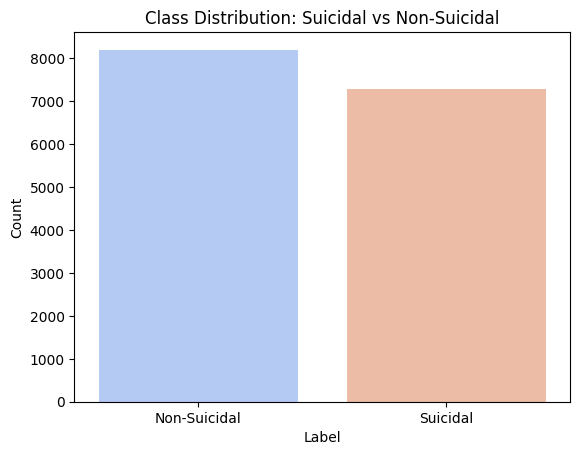

In [9]:
sns.countplot(data=df, x='label', hue='label', palette='coolwarm', legend=False)
plt.title('Class Distribution: Suicidal vs Non-Suicidal')
plt.xlabel('Label')
plt.ylabel('Count')

## Dataset Summary
Total posts: 15,476 (7,275 Suicidal, 8,201 Non-Suicidal)  
Class split: 47.01% vs 52.99%  

**The dataset is reasonably balanced. Severe imbalance correction is not required, and feature comparisons are less likely to be dominated by label skew.**

---

# Normalization of Counts

The engineered features were intentionally not normalized during preprocessing to avoid leakage from full-dataset statistics before train/test splitting. For EDA only, we compute temporary normalized ratios to compare classes more fairly.

This matters because longer posts naturally accumulate more raw counts; without normalization, we risk attributing length effects to linguistic effects.

In [10]:
df['word_count'] = df['text'].str.split().str.len()
print(df.groupby('label')['word_count'].mean())

label
Non-Suicidal    124.985855
Suicidal        163.210034
Name: word_count, dtype: float64


Suicidal posts average about **38 more words per post** than non-suicidal posts. This is a meaningful length difference, raw feature counts from suicidal posts would be inflated simply because those posts are longer, not necessarily because the features are more prevalent. We therefore normalize all count features by word count before any cross-class comparison.

In [11]:
df.columns

Index(['title', 'post', 'label', 'has_post', 'text', 'text_cleaned',
       'sub_metal_health_count', 'sub_dark_count', 'sub_support_count',
       'sub_total_count', 'first_person_singular', 'first_person_plural',
       'absolutist_count', 'negative_emotion', 'death_related', 'past_tense',
       'exclamation_count', 'question_count', 'upper_word_count',
       'upper_word_ratio', 'emoticon_positive', 'emoticon_negative',
       'emoticon_crying', 'emoticon_neutral', 'emoticon_heart',
       'emoticon_broken_heart', 'emoji_negative', 'emoji_positive',
       'emoji_crisis', 'emoji_implicit_distress', 'word_count'],
      dtype='str')

In [12]:
count_features = list(df.select_dtypes("int").loc[:, "first_person_singular":].columns)

count_features.remove("word_count")

for feature in count_features:
    df[f'{feature}_ratio'] = df[feature] / df['word_count']
    
rate_features = [f'{f}_ratio' for f in count_features]
print(df.groupby('label')[rate_features].mean())

              first_person_singular_ratio  first_person_plural_ratio  \
label                                                                  
Non-Suicidal                     0.102855                   0.006606   
Suicidal                         0.131494                   0.003228   

              absolutist_count_ratio  negative_emotion_ratio  \
label                                                          
Non-Suicidal                0.013578                0.001917   
Suicidal                    0.019514                0.006785   

              death_related_ratio  past_tense_ratio  exclamation_count_ratio  \
label                                                                          
Non-Suicidal             0.001405          0.019771                 0.016475   
Suicidal                 0.015611          0.011250                 0.003779   

              question_count_ratio  upper_word_count_ratio  \
label                                                        
Non-Suici

---

# EDA Questions

The sample preview raised a key observation: non-suicidal posts can carry strong negative emotion without any suicidal ideation. This means sentiment intensity alone is insufficient, the classification task demands understanding which specific linguistic signals, and which *combinations* of them, are truly predictive.

The three questions below build on each other. We first identify which features differ the most between classes (Q1), then ask whether those features work independently or together (Q2), and finally examine the cases where even the best features are expected to fail (Q3).

## Main Question

#### **How do linguistic and emotional patterns differ between suicidal and non-suicidal posts, and which features are most discriminative?**

## Subquestions
1. Which linguistic features show the strongest differences between classes?
2. Do suicidal posts exhibit distinct combinations of features?
3. What characteristics appear in distress-only posts and subtle suicidal posts that may cause classification errors?

---

## EDA Question 1: Which linguistic features show the strongest differences between classes?

We start with feature-level significance testing to identify which normalized linguistic markers best separate the two classes. These results guide feature prioritization for baseline classifiers and establish a reference point for model interpretation.

We compare class-wise means across all ratio features and test whether observed differences are statistically meaningful or likely due to chance.

In [13]:
suicidal_rates = df[df["label"] == "Suicidal"].loc[:, rate_features]
suicidal_rates

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
8201,0.055556,0.006173,0.018519,0.000000,0.006173,0.024691,0.000000,0.000000,0.006173,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8202,0.141538,0.003077,0.021538,0.003077,0.006154,0.018462,0.003077,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8203,0.135965,0.000000,0.043860,0.008772,0.000000,0.017544,0.000000,0.000000,0.004386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8204,0.152778,0.000000,0.020833,0.011574,0.006944,0.016204,0.013889,0.004630,0.004630,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8205,0.097826,0.003623,0.014493,0.000000,0.003623,0.032609,0.003623,0.003623,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15471,0.178571,0.000000,0.035714,0.035714,0.035714,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15472,0.153226,0.000000,0.056452,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15473,0.181818,0.000000,0.008264,0.016529,0.041322,0.016529,0.000000,0.000000,0.140496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15474,0.148438,0.000000,0.027344,0.011719,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
non_suicidal_rates = df[df["label"] == "Non-Suicidal"].loc[:, rate_features]
non_suicidal_rates

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
0,0.117391,0.008696,0.000000,0.0,0.0,0.013043,0.004348,0.004348,0.017391,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.074257,0.014851,0.000000,0.0,0.0,0.024752,0.000000,0.004950,0.004950,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.050000,0.025000,0.025000,0.0,0.0,0.000000,0.000000,0.000000,0.050000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.110220,0.008016,0.018036,0.0,0.0,0.004008,0.000000,0.000000,0.000000,0.002004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.081522,0.016304,0.010870,0.0,0.0,0.021739,0.000000,0.005435,0.005435,0.005435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8196,0.120690,0.017241,0.000000,0.0,0.0,0.034483,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8197,0.074074,0.024691,0.000000,0.0,0.0,0.049383,0.000000,0.000000,0.012346,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8198,0.047945,0.006849,0.013699,0.0,0.0,0.027397,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8199,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.222222,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


To identify the significant difference of features, we use `Welch's t-test`.

### Why we use a t-test here
We use a **Welch's independent-samples t-test** to evaluate whether mean feature differences between **Suicidal** and **Non-Suicidal** posts are statistically meaningful, not just random variation.

### How it works
- It compares group means relative to within-group spread.
- **Null hypothesis ($H_0$):** both groups have the same true feature mean.
- **Alternative hypothesis ($H_1$):** the true means are different.
- It returns a **t-statistic** (standardized group difference) and a **p-value** (how likely that difference is under $H_0$).

### Why Welch's version
Welch's test is preferred here because it is more robust when group variances are unequal and group sizes are not exactly identical.

### Decision rule
If `p < 0.05`, we reject $H_0$ and conclude the feature differs significantly between classes. We also inspect **Cohen's d** to prioritize effects that are practically meaningful, not only statistically significant.

In [15]:
def compare_feature(feature_name):
    """Compare single feature between classes."""
    suicidal_vals = df[df['label'] == 'Suicidal'][feature_name]
    non_suicidal_vals = df[df['label'] == 'Non-Suicidal'][feature_name]
    
    # T-test
    t_stat, p_value = stats.ttest_ind(suicidal_vals, non_suicidal_vals, equal_var=False)
    
    # Means
    mean_s = suicidal_vals.mean()
    mean_ns = non_suicidal_vals.mean()
    
    # Cohen's d
    pooled_std = np.sqrt((suicidal_vals.std()**2 + non_suicidal_vals.std()**2) / 2)
    cohens_d = (mean_s - mean_ns) / pooled_std
    
    return pd.Series({
        'Non-Suicidal Mean': mean_ns,
        'Suicidal Mean': mean_s,
        'Difference': mean_s - mean_ns,
        't-statistic': t_stat,
        'p-value': p_value,
        "Cohen's d": cohens_d
    })

# Apply to all features at once
stats_df = pd.DataFrame({
    feature: compare_feature(feature) 
    for feature in rate_features
}).T

stats_df['Significant'] = stats_df['p-value'] < 0.05

stats_df

,Non-Suicidal Mean,Suicidal Mean,Difference,t-statistic,p-value,Cohen's d,Significant
first_person_singular_ratio,0.102855,1.314943e-01,2.863962e-02,34.520052,3.277174e-251,0.557558,True
first_person_plural_ratio,0.006606,3.228059e-03,-3.378037e-03,-17.320994,1.458160e-66,-0.276423,True
absolutist_count_ratio,0.013578,1.951425e-02,5.935912e-03,17.840183,2.326854e-70,0.289970,True
negative_emotion_ratio,0.001917,6.785179e-03,4.867953e-03,25.466937,7.492841e-139,0.417409,True
death_related_ratio,0.001405,1.561062e-02,1.420560e-02,45.906770,0.000000e+00,0.758798,True
past_tense_ratio,0.019771,1.124961e-02,-8.520991e-03,-28.867977,2.499907e-178,-0.460394,True
exclamation_count_ratio,0.016475,3.778594e-03,-1.269630e-02,-6.431813,1.322840e-10,-0.105808,True
question_count_ratio,0.005038,6.151296e-03,1.112808e-03,3.657970,2.553658e-04,0.059775,True
upper_word_count_ratio,0.009066,8.690774e-03,-3.748366e-04,-0.413075,6.795581e-01,-0.006715,False
emoticon_positive_ratio,0.001168,5.867890e-05,-1.109797e-03,-13.832428,4.613569e-43,-0.216399,True


The full table includes features with varying levels of effect. We apply a practical filter: features must be both statistically significant and show a large effect size (|Cohen's d| > 0.5) to be considered strongly discriminative. This avoids over-indexing on features that are significant only because of sample size.

In [16]:
# Strongly discriminative: significant AND large effect size
significant_features = stats_df[
    stats_df["Significant"] & 
    ((stats_df["Cohen's d"] > 0.1) | (stats_df["Cohen's d"] < -0.1))
].index

significant_features

Index(['first_person_singular_ratio', 'first_person_plural_ratio',
       'absolutist_count_ratio', 'negative_emotion_ratio',
       'death_related_ratio', 'past_tense_ratio', 'exclamation_count_ratio',
       'emoticon_positive_ratio', 'emoji_positive_ratio'],
      dtype='str')

In [17]:
stats_df.loc[significant_features, ["p-value", "Cohen's d"]]

,p-value,Cohen's d
first_person_singular_ratio,3.277174e-251,0.557558
first_person_plural_ratio,1.458160e-66,-0.276423
absolutist_count_ratio,2.326854e-70,0.289970
negative_emotion_ratio,7.492841e-139,0.417409
death_related_ratio,0.000000e+00,0.758798
past_tense_ratio,2.499907e-178,-0.460394
exclamation_count_ratio,1.322840e-10,-0.105808
emoticon_positive_ratio,4.613569e-43,-0.216399
emoji_positive_ratio,9.129735e-18,-0.134565


Two features clear the large-effect threshold: **death-related terms** (d = 0.76) and **first-person singular pronouns** (d = 0.56). These are the strongest single-feature separators in the dataset.

However, several medium-effect features also carry meaningful signal and are worth noting:

| Feature | Cohen's d | Direction | Interpretation |
|---|---|---|---|
| `death_related_ratio` | 0.76 | Higher in Suicidal | Most discriminative feature; direct suicidality marker |
| `first_person_singular_ratio` | 0.56 | Higher in Suicidal | Self-focused narration associated with ideation |
| `past_tense_ratio` | -0.46 | Higher in Non-Suicidal | Reflective storytelling without ideation |
| `negative_emotion_ratio` | 0.42 | Higher in Suicidal | General distress, meaningful but not sufficient alone |
| `absolutist_count_ratio` | 0.29 | Higher in Suicidal | Rigid, black-and-white thinking patterns |
| `exclamation_count_ratio` | -0.11 | Higher in Non-Suicidal | Expressive intensity absent in suicidal posts |

The **exclamation mark finding is counterintuitive**: non-suicidal posts use exclamation marks more than the rate of suicidal posts. This makes sense on reflection, high emotional intensity in non-suicidal posts is often outward-facing (excitement, frustration, venting), while suicidal posts tend toward a quieter, although with some exceptions. Similarly, the **past tense** being more common in non-suicidal posts suggests reflective storytelling rather than present-tense distress.

In [46]:
significant_subset = df.loc[:, [*significant_features, "label"]]
significant_subset

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,emoticon_positive_ratio,emoji_positive_ratio,label
0,0.117391,0.008696,0.000000,0.000000,0.000000,0.013043,0.004348,0.000000,0.0,Non-Suicidal
1,0.074257,0.014851,0.000000,0.000000,0.000000,0.024752,0.000000,0.000000,0.0,Non-Suicidal
2,0.050000,0.025000,0.025000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,Non-Suicidal
3,0.110220,0.008016,0.018036,0.000000,0.000000,0.004008,0.000000,0.002004,0.0,Non-Suicidal
4,0.081522,0.016304,0.010870,0.000000,0.000000,0.021739,0.000000,0.005435,0.0,Non-Suicidal
...,...,...,...,...,...,...,...,...,...,...
15471,0.178571,0.000000,0.035714,0.035714,0.035714,0.000000,0.000000,0.000000,0.0,Suicidal
15472,0.153226,0.000000,0.056452,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,Suicidal
15473,0.181818,0.000000,0.008264,0.016529,0.041322,0.016529,0.000000,0.000000,0.0,Suicidal
15474,0.148438,0.000000,0.027344,0.011719,0.000000,0.000000,0.000000,0.000000,0.0,Suicidal


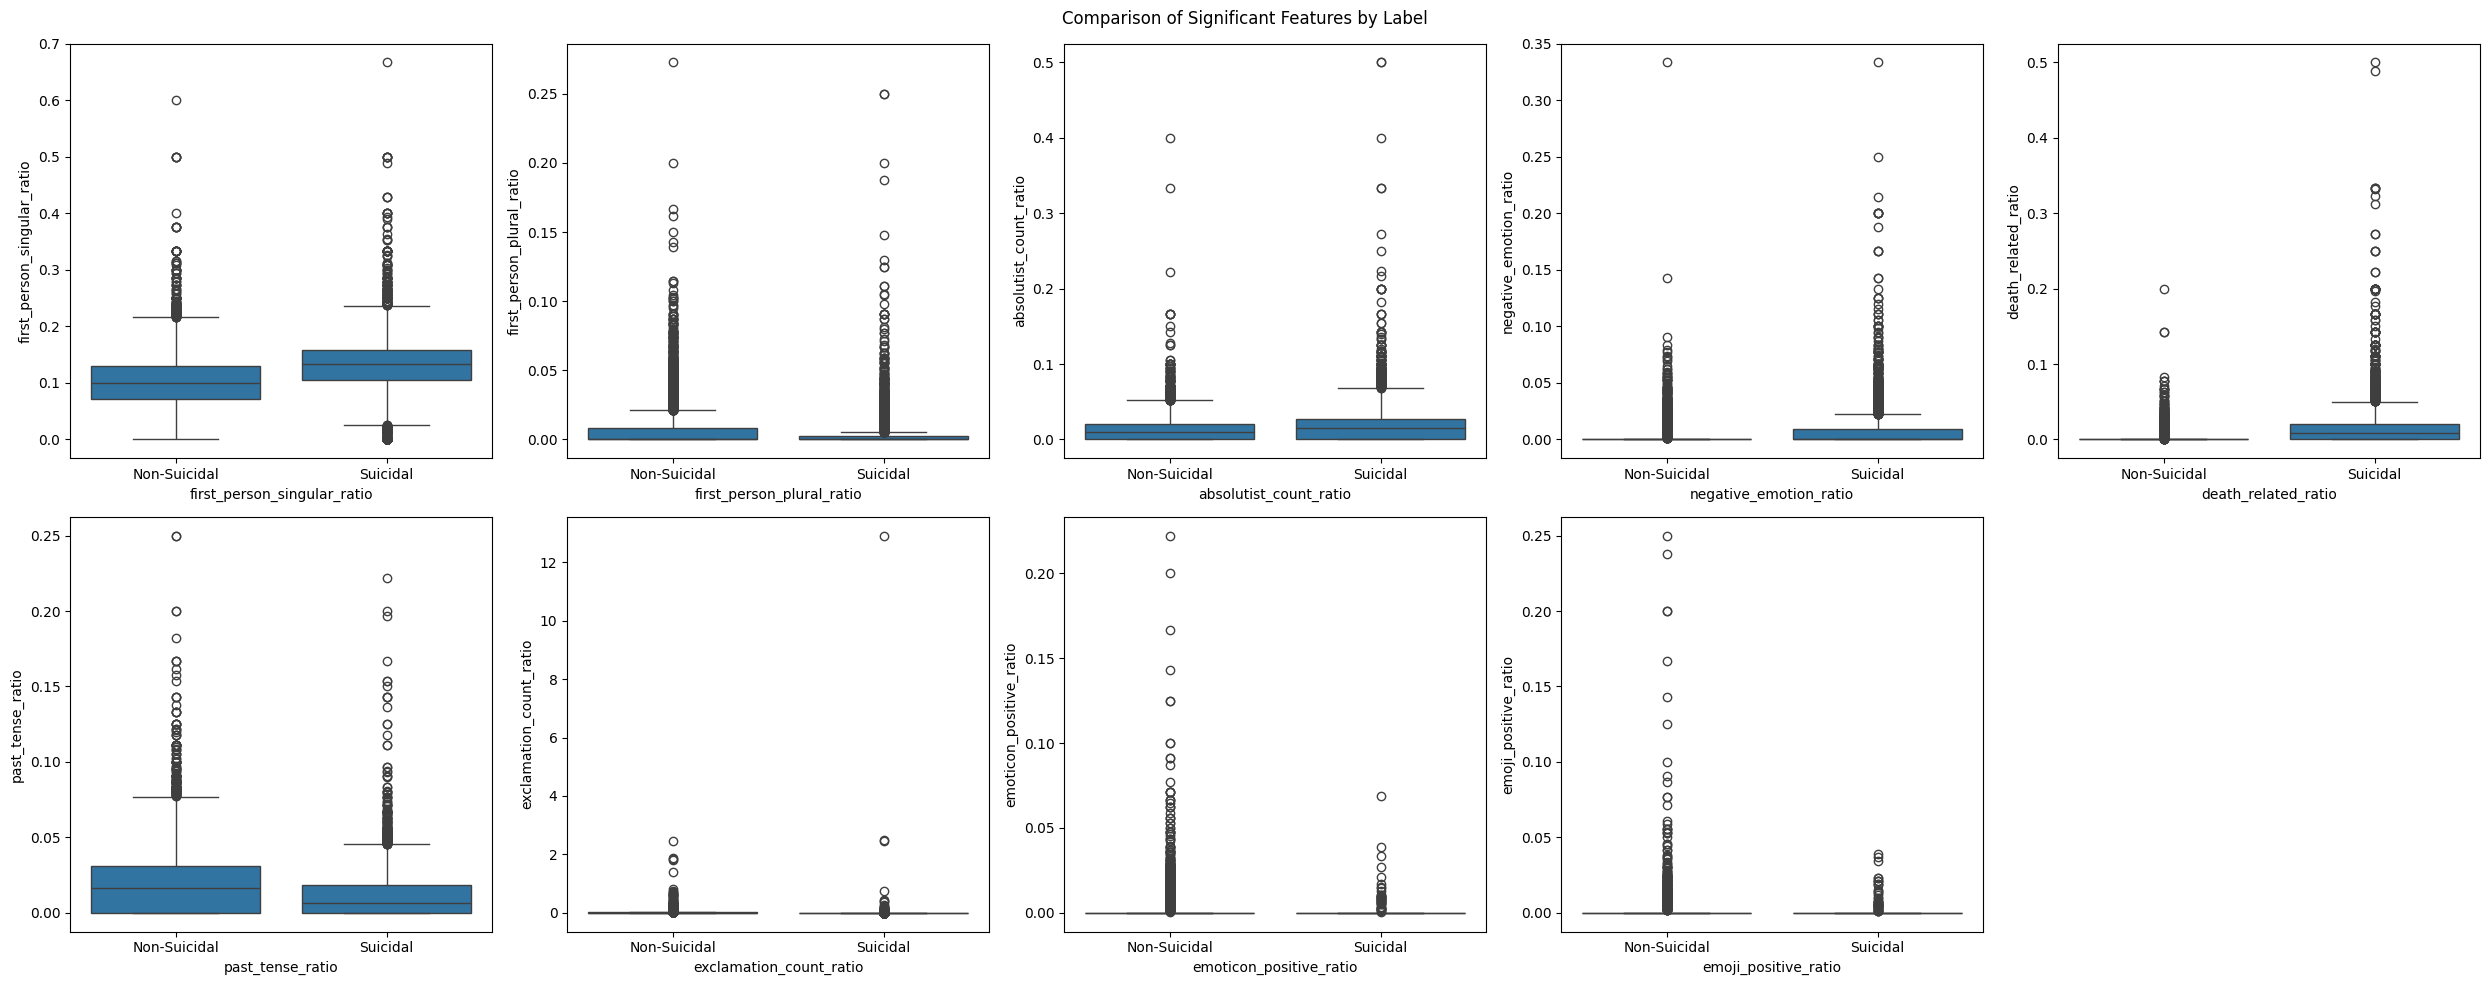

In [ ]:
row = 2
col = int(np.ceil(len(significant_features) / 2))

fig, ax = plt.subplots(row, col, figsize=[25, 10])
ax = ax.flatten()

for i in range(len(significant_features)):
    sns.boxplot(data=significant_subset, x="label", y=significant_features[i], ax=ax[i])
    ax[i].set_xlabel(significant_features[i])

for j in range(len(significant_features), len(ax)):
    fig.delaxes(ax[j])

fig.suptitle('Comparison of Significant Features by Label')
plt.tight_layout()

The box plots confirm the class separation for both features. The distributions are skewed right in both cases, most posts have low values, with a long tail of high-usage posts. This skew is more pronounced for `death_related_ratio`, where the majority of non-suicidal posts cluster near zero while suicidal posts show a much wider spread.

These two features are strong candidates for interpretable baseline modeling. The remaining medium-effect features (past tense, negative emotion, absolutist language, exclamation marks) provide supporting signal and may prove useful in combination, which motivates the next question.

---

## EDA Question 2: Do suicidal posts exhibit distinct combinations of features?

Knowing which individual features differ is a starting point, but classifiers also learn interactions. A post might have moderate first-person usage and moderate absolutist language, neither elevated enough to trigger on their own, but their combined occurrence could still be a reliable suicidal signal. Here we inspect within-class feature correlations to see whether the two classes show structurally different feature co-occurrence patterns.

We compute correlation matrices separately for each class, then compare the strongest co-occurring feature pairs. A meaningful difference in correlation structure between classes would suggest that suicidality is partly encoded in *how features combine*, not just which features are elevated.

In [20]:
# Use only linguistic and stylistic features — exclude subreddit metadata
linguistic_features = [
    'first_person_singular', 'first_person_plural', 'absolutist_count',
    'negative_emotion', 'death_related', 'past_tense',
    'exclamation_count', 'question_count', 'upper_word_count'
]

linguistic_df = df[linguistic_features + ['label']]

In [21]:
ratio_correlations_suicidal = linguistic_df[linguistic_df["label"] == "Suicidal"].drop(["label"], axis=1).corr()
ratio_correlations_non_suicidal = linguistic_df[linguistic_df["label"] == "Non-Suicidal"].drop(["label"], axis=1).corr()

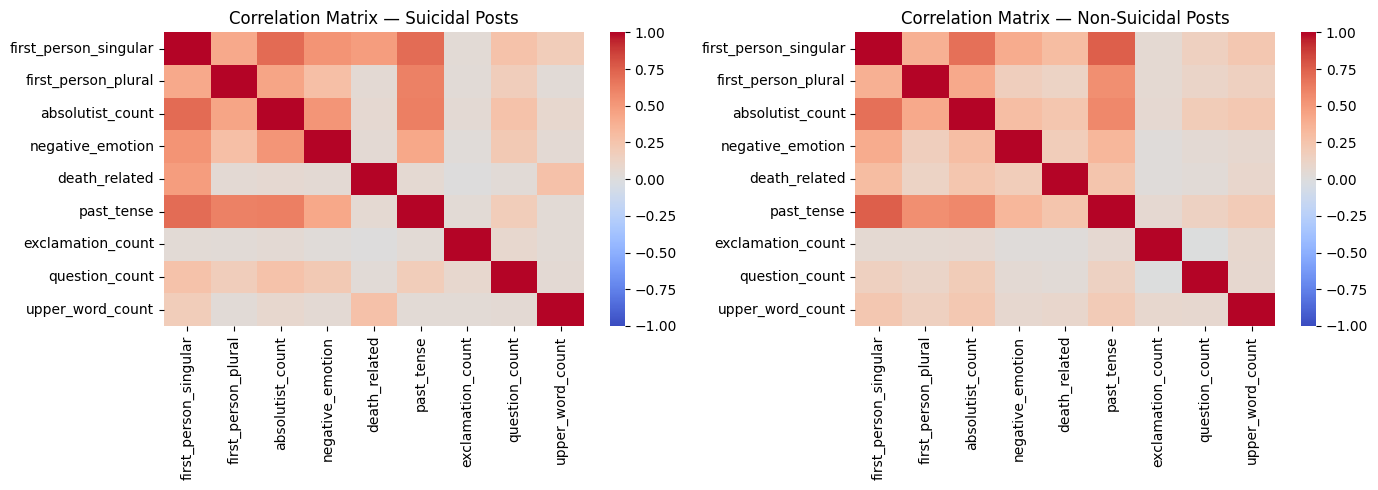

In [22]:
fig, axes = plt.subplots(1, 2, figsize=[14, 5])
sns.heatmap(ratio_correlations_suicidal, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title("Correlation Matrix — Suicidal Posts")
sns.heatmap(ratio_correlations_non_suicidal, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title("Correlation Matrix — Non-Suicidal Posts")
plt.tight_layout()

In [23]:
def get_good_correlations(correlation_mat):
    good_ratio_correlations =  correlation_mat.map(lambda x : (x > 0.3 or x < -0.3)) #  0.3 < x < -0.3
    good_ratio_correlations_indices = list(zip(*np.where(good_ratio_correlations)))

    indices = correlation_mat.index
    good_ratio_correlations_vals = []
    index_buffer = [] # list of indices so reverses are not included

    for index in good_ratio_correlations_indices:
        i, j = index

        if i != j:
            row, col = indices[i], indices[j]

            if (col, row) not in index_buffer:
                good_ratio_correlations_vals.append({"key": (row, col), "val": correlation_mat.loc[row, col]})
                index_buffer.append((row, col))

    good_ratio_correlations_vals.sort(key=lambda x: x["val"], reverse=True)

    good_ratio_correlations_vals = pd.DataFrame(good_ratio_correlations_vals)

    return good_ratio_correlations_vals

In [24]:
print("Top correlated pairs — Suicidal posts")
good_ratio_correlations_suicidal = get_good_correlations(ratio_correlations_suicidal)
good_ratio_correlations_suicidal

Top correlated pairs — Suicidal posts


,key,val
0,"(first_person_singular, absolutist_count)",0.707225
1,"(first_person_singular, past_tense)",0.699225
2,"(absolutist_count, past_tense)",0.620555
3,"(first_person_plural, past_tense)",0.611319
4,"(first_person_singular, negative_emotion)",0.524926
5,"(absolutist_count, negative_emotion)",0.518695
6,"(first_person_singular, death_related)",0.479908
7,"(first_person_plural, absolutist_count)",0.445055
8,"(negative_emotion, past_tense)",0.426242
9,"(first_person_singular, first_person_plural)",0.414896


In [25]:
print("Top correlated pairs — Non-Suicidal posts")
good_ratio_correlations_non_suicidal = get_good_correlations(ratio_correlations_non_suicidal)
good_ratio_correlations_non_suicidal

Top correlated pairs — Non-Suicidal posts


,key,val
0,"(first_person_singular, past_tense)",0.751211
1,"(first_person_singular, absolutist_count)",0.686360
2,"(absolutist_count, past_tense)",0.583271
3,"(first_person_plural, past_tense)",0.549580
4,"(first_person_plural, absolutist_count)",0.415805
5,"(first_person_singular, negative_emotion)",0.405126
6,"(first_person_singular, first_person_plural)",0.382219
7,"(negative_emotion, past_tense)",0.339296
8,"(first_person_singular, death_related)",0.303966


The top pairs differ between classes in a meaningful way. To visualize this, we plot the strongest class-specific pair for each group, using only posts from that class.

Text(0.5, 1.0, '[SUICIDAL] first_person_singular vs absolutist_count')

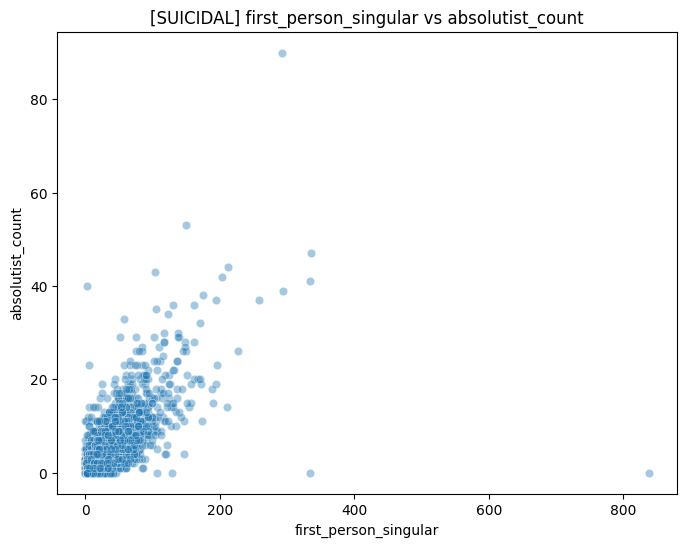

In [26]:
# Strongest pair in suicidal posts: first_person_singular + absolutist_count
suicidal_only = df[df['label'] == 'Suicidal']
plt.figure(figsize=[8, 6])
sns.scatterplot(data=suicidal_only, x="first_person_singular", y="absolutist_count", alpha=0.4)
plt.title("[SUICIDAL] first_person_singular vs absolutist_count")

Text(0.5, 1.0, '[NON-SUICIDAL] first_person_singular vs past_tense')

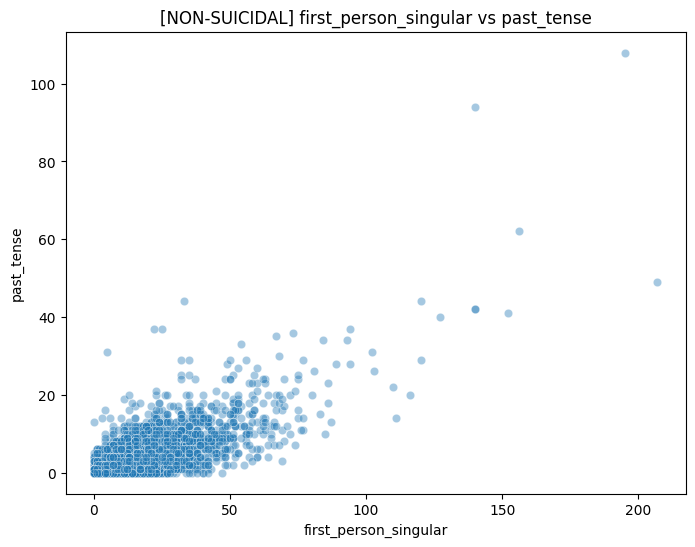

In [27]:
# Strongest pair in non-suicidal posts: first_person_singular + past_tense
non_suicidal_only = df[df['label'] == 'Non-Suicidal']
plt.figure(figsize=[8, 6])
sns.scatterplot(data=non_suicidal_only, x="first_person_singular", y="past_tense", alpha=0.4)
plt.title("[NON-SUICIDAL] first_person_singular vs past_tense")

The correlation structure tells a coherent story. In **suicidal posts**, first-person singular language co-occurs most strongly with absolutist wording (r = 0.71), the combination of self-focus and radical, all-or-nothing thinking is characteristic of suicidal ideation in posts. In **non-suicidal posts**, first-person singular co-occurs most strongly with past tense (r = 0.75), a pattern consistent with reflective personal storytelling/reminiscing rather than present distress.

This distinction matters for classification: a model that only looks at first-person usage in isolation would miss this structural difference entirely. Models that can capture feature interactions, whether through engineered interaction terms or learned representations, are better to utilize of this pattern for classification.

---

## EDA Question 3: What characteristics appear in distress-only posts and subtle suicidal posts that may cause classification errors?

The two previous questions established what the features can detect. This question focuses on what they *cannot*. Even with strong discriminative features, some posts will be difficult to classify. Examples of these are non-suicidal posts that look linguistically similar to suicidal ones (false positive risk) and suicidal posts that avoid the expected markers entirely (false negative risk).

Understanding these failure modes define the performance ceiling for any lexical model and motivate the need for context-sensitive representations.

We define two ambiguous subgroups and compare their feature profiles against their respective class averages. This lets us see not just *which posts* are ambiguous, but *which features* help or fail on each type.

In [28]:
ratio_columns = list(df.loc[:, "first_person_singular_ratio":].columns)

In [29]:
q75_by_class = df.groupby("label")[ratio_columns].quantile(0.75)
q75_by_class

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
label,,,,,,,,,,,,,,,,,,,
Non-Suicidal,0.129630,0.008403,0.021008,0.000000,0.00,0.030769,0.014706,0.003236,0.005882,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Suicidal,0.157895,0.002204,0.027322,0.009009,0.02,0.018182,0.000000,0.004237,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
q25_by_class = df.groupby("label")[ratio_columns].quantile(0.25)
q25_by_class

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
label,,,,,,,,,,,,,,,,,,,
Non-Suicidal,0.071429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Suicidal,0.104961,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Two sparsity findings are worth noting before defining the groups:
- The 75th percentile of `negative_emotion_ratio` for non-suicidal posts is **0** — meaning at least 75% of non-suicidal posts contain no negative emotion tokens at all.
- The 25th percentile of `death_related_ratio` for suicidal posts is also **0** — meaning at least 25% of suicidal posts contain no death-related terms.

The second finding suggests that even the strongest lexical feature (Cohen's d = 0.76) scores zero for a quarter of suicidal posts. This establishes a baseline on any purely keyword-based model's recall.

In [31]:
# Ambiguous non-suicidal: high negative emotion but no death-related terms
pd.set_option('display.max_colwidth', None)
ns_q75_neg = q75_by_class.loc['Non-Suicidal', 'negative_emotion_ratio']

ambiguous_nonsuicidal = df[
    (df['label'] == 'Non-Suicidal') &
    (df['negative_emotion_ratio'] >= ns_q75_neg) &
    (df['death_related_ratio'] == 0)
]

print("Ambiguous Non-Suicidal Posts")
print(f"Defined as: negative_emotion_ratio >= {ns_q75_neg} (75th pct) AND death_related_ratio == 0")
print(f"Group size: {len(ambiguous_nonsuicidal)} posts")
display(ambiguous_nonsuicidal["text_cleaned"].sample(10, random_state=random_seed))

Ambiguous Non-Suicidal Posts
Defined as: negative_emotion_ratio >= 0.0 (75th pct) AND death_related_ratio == 0
Group size: 7209 posts


363                      I just got my dream job!!!!! I am so excited and I just want to share with anyone and everyone. I just got my dream job!!!! It’s something I don’t have much experience with, so I’m nervous, but so happy. Not totally sure about the start date yet, but soon. I’m going to be an organizer for my state’s public education union. Anyone with labor organizing experience, any tips? This will improve so many things in my life. Literally double my current salary. I will never again have to see a certain coworker who is one of the worst human beings I have ever met. It will be wonderful experience for my future career goals. I’ll get to use what I’m learning in grad school. I will have a little more flexibility in my schedule. More time off. I’ll actually be treated like a responsible professional adult. I’ll be a part of an effective union!
445                                                                                                                                  

In [32]:
# Subtle suicidal: suicidal posts with no death-related terms (bottom 25%)
pd.set_option('display.max_colwidth', None)
s_q25_death = df[df['label'] == 'Suicidal']['death_related_ratio'].quantile(0.25)

subtle_suicidal = df[
    (df['label'] == 'Suicidal') &
    (df['death_related_ratio'] <= s_q25_death)
]

print("Subtle Suicidal Posts")
print(f"Defined as: death_related_ratio <= {s_q25_death} (25th pct within suicidal class)")
print(f"Group size: {len(subtle_suicidal)} posts")
display(subtle_suicidal["text_cleaned"].sample(10, random_state=random_seed))

Subtle Suicidal Posts
Defined as: death_related_ratio <= 0.0 (25th pct within suicidal class)
Group size: 2286 posts


13087                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Now we compare the feature profiles of these ambiguous groups against their class averages to see which features compensate and which ones fail.

In [ ]:
# Focus on the most interpretable features for the profile comparison
profile_features = [
    'first_person_singular_ratio', 'first_person_plural_ratio',
    'absolutist_count_ratio', 'negative_emotion_ratio',
    'death_related_ratio', 'past_tense_ratio',
    'exclamation_count_ratio', 'question_count_ratio'
]

profile_comparison = pd.DataFrame({
    'All Non-Suicidal': df[df['label']=='Non-Suicidal'][profile_features].mean(),
    'Ambiguous Non-Suicidal': ambiguous_nonsuicidal[profile_features].mean(),
    'All Suicidal': df[df['label']=='Suicidal'][profile_features].mean(),
    'Subtle Suicidal': subtle_suicidal[profile_features].mean(),
})

profile_comparison.round(4)

,All Non-Suicidal,Ambiguous Non-Suicidal,All Suicidal,Subtle Suicidal
first_person_singular_ratio,0.1029,0.1030,0.1315,0.1291
first_person_plural_ratio,0.0066,0.0066,0.0032,0.0031
absolutist_count_ratio,0.0136,0.0136,0.0195,0.0207
negative_emotion_ratio,0.0019,0.0019,0.0068,0.0078
death_related_ratio,0.0014,0.0000,0.0156,0.0000
past_tense_ratio,0.0198,0.0195,0.0112,0.0096
exclamation_count_ratio,0.0165,0.0173,0.0038,0.0099
question_count_ratio,0.0050,0.0052,0.0062,0.0081


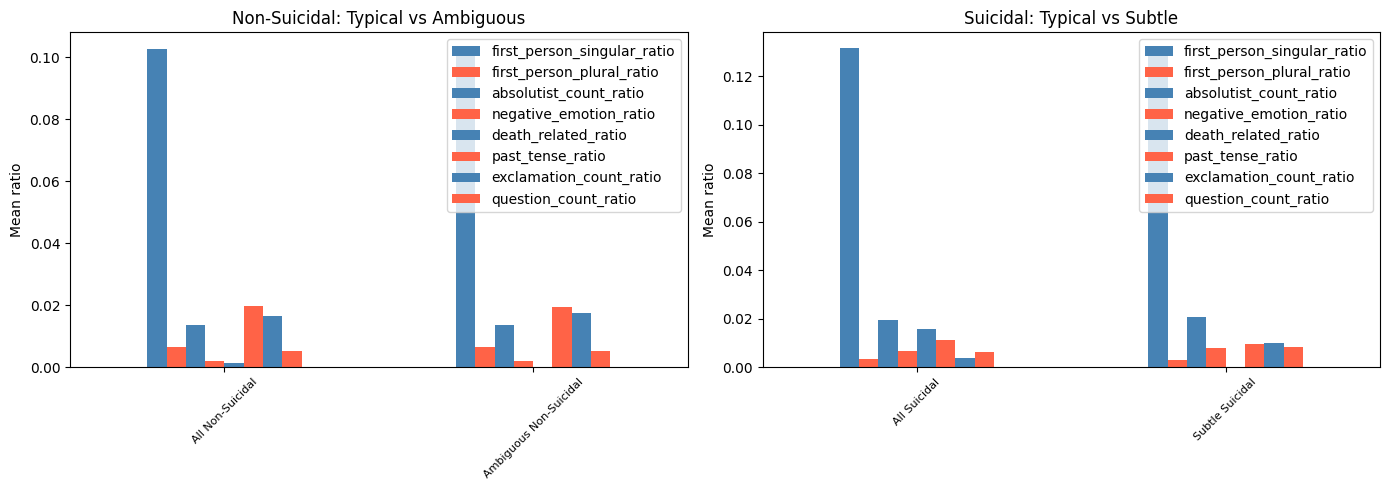

In [34]:
# Visualize the profile comparison
fig, axes = plt.subplots(1, 2, figsize=[14, 5])

profile_comparison[['All Non-Suicidal', 'Ambiguous Non-Suicidal']].T.plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], rot=45
)
axes[0].set_title('Non-Suicidal: Typical vs Ambiguous')
axes[0].set_ylabel('Mean ratio')
axes[0].tick_params(axis='x', labelsize=8)

profile_comparison[['All Suicidal', 'Subtle Suicidal']].T.plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], rot=45
)
axes[1].set_title('Suicidal: Typical vs Subtle')
axes[1].set_ylabel('Mean ratio')
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()

The profile comparison reveals different failure modes for each group.

**Ambiguous Non-Suicidal posts** are elevated on negative emotion by definition, but the profile shows they also tend to have higher exclamation mark and question mark usage than typical non-suicidal posts. These are stylistic markers of outward expression (i.e., venting, seeking advice and sharing frustration) that help distinguish them from suicidal writing even when emotional language is high. A classifier with exclamation and question features would have some signal to work with.

**Subtle Suicidal posts** are more difficult. By definition they score zero on `death_related_ratio`, but notably, other features do not compensate, the profile is nearly flat compared to typical suicidal posts across all remaining features. `first_person_singular_ratio` stays comparable, and absolutist and negative emotion  language show only marginal differences. These posts are not detectable through any  alternative lexical signal; the suicidality is carried entirely by meaning and context  rather than vocabulary. Their ideation is expressed through:

- Euphemistic framing: *"give up", "not be around", "vacation from everything"*
- Implicit planning without explicit death words: specific dosage or method references that bypass the death-related lexicon
- Short, resigned statements that are lexically weak but contextually unambiguous
- Abstract or dissociative language: *"catatonic state of unbeing", "I no longer have this border"*

These cases represent a hard limit for purely lexical approaches. No amount of feature engineering can recover suicidal intent that is deliberately or unconsciously expressed without suicidal vocabulary.

This finding directly motivates the use of context-sensitive representations in the classification stage. A bag-of-words or TF-IDF model operates on token presence and frequency, it cannot distinguish *"I just want to give up"* (suicidal resignation) from *"I give up trying to fix this bug"* (casual frustration) without the surrounding context that makes the meaning unambiguous. However, they do serve as a good baseline for comparison.

---

# Conclusion

The analysis converges on a consistent pattern: suicidality leaves traces in language, but those traces are neither uniform nor sufficient on their own.

**What the features reveal:**

Death-related language is the single strongest discriminative signal (Cohen's d = 0.76), followed by first-person singular pronoun usage (d = 0.56). Together, these two features reflect a pattern of self-focused narration oriented explicitly toward mortality, a combination that is relatively rare in non-suicidal posts. Several medium-effect features add supporting signal: past-tense narration and exclamation marks are both more common in non-suicidal posts, reflecting a reflective, outward-expressive register that differs from the quieter internal tone of suicidal writing.

**What the interactions reveal:**

Suicidal posts show a tighter dependency between first-person singular and absolutist language (r = 0.71) compared to non-suicidal posts, where first-person singular couples more strongly with past tense (r = 0.75). This structural difference suggests that suicidality is partly encoded in *how features co-occur*, not only which features are elevated. Models that can learn feature interactions are better equipped to exploit this.

**What the ambiguous cases reveal:**

At least 25% of suicidal posts contain zero death-related terms, the strongest lexical feature scores zero for a substantial fraction of the positive class. These subtle cases express ideation through euphemism, implicit planning, resignation, and dissociative language that no keyword list can reliably capture. This sets a performance ceiling for any purely keyword-based model and identifies the specific failure mode that context-sensitive representations are designed to address.

**Implications for the classification stage:**
- Start with interpretable baselines (logistic regression on normalized ratio features) to establish a lexical performance ceiling.
- Evaluate model errors specifically on the ambiguous subsets identified here — false positive risk from high-distress non-suicidal posts, and false negative risk from subtle suicidal posts with no death-related terms.
- Use context-sensitive representations (e.g., fine-tuned transformer embeddings) to target the subtle suicidal cases that lexical models are structurally unable to handle.